# Urban Demand Forecasting — RQ1 Standalone Kaggle Notebook

This notebook implements the methodology for **RQ1** from the thesis proposal on shared-mobility demand forecasting using cross-modal fusion of weather, calendar, and neighborhood context.

It is Kaggle-ready and auto-fetches the UCI Bike Sharing Dataset if `hour.csv` is not already available. Turn **Internet = On** in Kaggle Notebook Settings.

Outputs produced by this notebook:
- at least **4 PDF figures** displayed inside the notebook and saved to `/kaggle/working/.../figures_pdf/`
- at least **3 CSV tables** saved to `/kaggle/working/.../tables_csv/`
- one final ZIP containing all outputs for this research question

Important dataset note: UCI Bike Sharing contains weather/calendar/hourly demand but no real station-level neighborhood metadata. The notebook therefore creates a transparent neighborhood-context proxy so the full research-question pipeline can run end-to-end. For final thesis-grade experiments, replace the proxy section with real station/zone/POI/land-use metadata.



In [4]:
RQ = 'RQ1'

# ============================================================
# Common setup: auto-fetch dataset, preprocessing, metrics, models
# ============================================================
import os, glob, zipfile, urllib.request, warnings, shutil, math, json
from pathlib import Path
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Thesis-ready plotting defaults: larger fonts, clean PDF export, readable axes.
plt.rcParams.update({
    'figure.dpi': 140,
    'savefig.dpi': 300,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
})


from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except Exception:
    HAS_XGB = False

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

RQ = globals().get('RQ', 'RQ')
OUTPUT_DIR = Path('/kaggle/working') if Path('/kaggle/working').exists() else Path.cwd()
OUTPUT_DIR = OUTPUT_DIR / f'urban_demand_{RQ}_outputs'
FIG_DIR = OUTPUT_DIR / 'figures_pdf'
TAB_DIR = OUTPUT_DIR / 'tables_csv'
for d in [OUTPUT_DIR, FIG_DIR, TAB_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('Output directory:', OUTPUT_DIR)

def section(title):
    print('\n' + '='*90)
    print(title)
    print('='*90)

def save_table(df, name):
    path = TAB_DIR / f'{name}.csv'
    df.to_csv(path, index=False)
    print(f'Saved table: {path}')
    display(df.head(20))
    return path

def save_fig(name):
    path = FIG_DIR / f'{name}.pdf'
    plt.tight_layout()
    plt.savefig(path, format='pdf', bbox_inches='tight')
    print(f'Saved figure: {path}')
    plt.show()
    return path

def find_or_download_hour_csv():
    candidates = []
    search_roots = ['/kaggle/input', '/kaggle/working', str(Path.cwd()), '/mnt/data']
    for root in search_roots:
        if Path(root).exists():
            candidates.extend(glob.glob(os.path.join(root, '**', 'hour.csv'), recursive=True))
    if candidates:
        print('Found hour.csv:', candidates[0])
        return candidates[0]

    print('hour.csv not found. Downloading UCI Bike Sharing Dataset...')
    url = 'https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip'
    zip_path = OUTPUT_DIR / 'bike_sharing_dataset.zip'
    try:
        urllib.request.urlretrieve(url, zip_path)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(OUTPUT_DIR / 'uci_bike_sharing')
        found = glob.glob(str(OUTPUT_DIR / 'uci_bike_sharing' / '**' / 'hour.csv'), recursive=True)
        if not found:
            raise FileNotFoundError('Downloaded zip did not contain hour.csv')
        print('Downloaded and extracted:', found[0])
        return found[0]
    except Exception as e:
        raise RuntimeError(
            'Could not fetch hour.csv automatically. On Kaggle, enable Internet in Notebook Settings, '
            'or add a dataset containing UCI Bike Sharing hour.csv. Original error: ' + str(e)
        )

def load_bike_data():
    hour_path = find_or_download_hour_csv()
    df = pd.read_csv(hour_path)
    df['dteday'] = pd.to_datetime(df['dteday'])
    df['datetime'] = df['dteday'] + pd.to_timedelta(df['hr'], unit='h')
    df = df.sort_values('datetime').reset_index(drop=True)
    print('Loaded shape:', df.shape)
    print('Date range:', df['datetime'].min(), 'to', df['datetime'].max())
    return df

def build_features(raw):
    df = raw.copy().sort_values('datetime').reset_index(drop=True)
    # Demand regimes aligned with the proposal: commute, leisure, weekend, holiday, severe weather, mixed.
    commute = (df['workingday'].eq(1)) & (df['hr'].isin([7,8,9,16,17,18,19]))
    leisure = (df['hr'].between(10,20)) & ((df['weekday'].isin([0,6])) | (df['holiday'].eq(1)))
    severe = df['weathersit'].ge(3)
    conditions = [severe, df['holiday'].eq(1), commute, leisure, df['weekday'].isin([0,6])]
    labels = ['Severe Weather', 'Holiday', 'Commute', 'Leisure', 'Weekend']
    df['regime'] = np.select(conditions, labels, default='Mixed Regime')

    # Transparent proxy neighborhood semantics because UCI has no station / POI metadata.
    # For a final thesis, replace this block with real station-level POI / land-use metadata.
    df['neighborhood_type'] = np.select(
        [commute & df['hr'].isin([7,8,9]), commute & df['hr'].isin([16,17,18,19]), leisure & df['season'].isin([2,3]), df['hr'].between(10,15) & df['workingday'].eq(1), severe],
        ['CBD', 'Residential', 'Tourist', 'University', 'Transit Hub'],
        default='Mixed-use'
    )
    # Pseudo-stations to enable cross-station and neighborhood experiments on UCI.
    df['station_id'] = (df['neighborhood_type'].astype('category').cat.codes * 10 + (df['hr'] // 4)).astype(int)
    df['station_id'] = 'S' + df['station_id'].astype(str).str.zfill(2)

    # Neighborhood feature proxies created from available temporal/weather indicators.
    nmap = {
        'CBD':          [0.20, 0.85, 0.95, 0.15, 0.25, 0.90],
        'Residential':  [0.90, 0.25, 0.30, 0.20, 0.15, 0.45],
        'University':   [0.35, 0.45, 0.30, 0.95, 0.30, 0.60],
        'Tourist':      [0.25, 0.55, 0.40, 0.25, 0.95, 0.65],
        'Transit Hub':  [0.35, 0.65, 0.55, 0.20, 0.35, 1.00],
        'Mixed-use':    [0.50, 0.55, 0.50, 0.45, 0.45, 0.65]
    }
    cols = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
    for j,c in enumerate(cols):
        df[c] = df['neighborhood_type'].map(lambda x: nmap[x][j]).astype(float)

    # Time encodings
    df['hr_sin'] = np.sin(2*np.pi*df['hr']/24)
    df['hr_cos'] = np.cos(2*np.pi*df['hr']/24)
    df['weekday_sin'] = np.sin(2*np.pi*df['weekday']/7)
    df['weekday_cos'] = np.cos(2*np.pi*df['weekday']/7)
    df['month'] = df['datetime'].dt.month
    df['month_sin'] = np.sin(2*np.pi*df['month']/12)
    df['month_cos'] = np.cos(2*np.pi*df['month']/12)
    df['is_commute'] = commute.astype(int)
    df['is_weekend'] = df['weekday'].isin([0,6]).astype(int)

    for lag in [1,2,3,6,12,24,48,168]:
        df[f'lag_{lag}'] = df['cnt'].shift(lag)
    for win in [3,6,24,168]:
        df[f'roll_mean_{win}'] = df['cnt'].shift(1).rolling(win).mean()
        df[f'roll_std_{win}'] = df['cnt'].shift(1).rolling(win).std()
    df['diff_1'] = df['cnt'].diff(1).shift(1)
    df['diff_24'] = df['cnt'].diff(24).shift(1)
    df = df.dropna().reset_index(drop=True)
    return df

RAW_DF = load_bike_data()
DATA = build_features(RAW_DF)
print('Feature-ready shape:', DATA.shape)

TARGET = 'cnt'
base_temporal = ['hr','hr_sin','hr_cos','weekday','weekday_sin','weekday_cos','month_sin','month_cos', 'season', 'yr']
weather_features = ['temp','atemp','hum','windspeed','weathersit']
calendar_features = ['holiday','workingday','is_weekend','is_commute']
lag_features = [c for c in DATA.columns if c.startswith('lag_') or c.startswith('roll_') or c.startswith('diff_')]
neighborhood_features = ['residential_density','commercial_density','office_intensity','education_density','tourism_poi_density','transit_access']
cat_features = ['neighborhood_type','regime']

FEATURE_SETS = {
    'Historical Average': [],
    'Temporal Only': base_temporal + lag_features,
    'Temporal + Weather': base_temporal + lag_features + weather_features,
    'Temporal + Calendar': base_temporal + lag_features + calendar_features,
    'Temporal + Neighborhood': base_temporal + lag_features + neighborhood_features + ['neighborhood_type'],
    'Weather + Calendar': base_temporal + lag_features + weather_features + calendar_features,
    'Full Cross-Modal Fusion': base_temporal + lag_features + weather_features + calendar_features + neighborhood_features + ['neighborhood_type']
}

def time_split(df, train_frac=0.70, val_frac=0.15):
    n = len(df)
    train_end = int(n*train_frac)
    val_end = int(n*(train_frac+val_frac))
    return df.iloc[:train_end].copy(), df.iloc[train_end:val_end].copy(), df.iloc[val_end:].copy()

TRAIN, VAL, TEST = time_split(DATA)
print('Train/Val/Test:', TRAIN.shape, VAL.shape, TEST.shape)


def make_preprocessor(features):
    numeric = [f for f in features if f not in ['neighborhood_type','regime','station_id']]
    categorical = [f for f in features if f in ['neighborhood_type','regime','station_id']]
    transformers = []
    if numeric:
        transformers.append(('num', Pipeline([('impute', SimpleImputer(strategy='median')), ('scale', StandardScaler())]), numeric))
    if categorical:
        transformers.append(('cat', Pipeline([('impute', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical))
    return ColumnTransformer(transformers, remainder='drop')


def build_model(model_name='rf', features=None):
    if features is None:
        features = FEATURE_SETS['Full Cross-Modal Fusion']
    if model_name == 'ridge':
        reg = Ridge(alpha=2.0)
    elif model_name == 'gbr':
        reg = GradientBoostingRegressor(random_state=RANDOM_STATE, n_estimators=160, learning_rate=0.05, max_depth=3)
    elif model_name == 'extra':
        reg = ExtraTreesRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    elif model_name == 'xgb' and HAS_XGB:
        reg = XGBRegressor(random_state=RANDOM_STATE, n_estimators=220, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective='reg:squarederror', n_jobs=-1)
    else:
        reg = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=160, max_depth=14, min_samples_leaf=2, n_jobs=-1)
    return Pipeline([('prep', make_preprocessor(features)), ('model', reg)])


def metrics(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    denom = np.sum(np.abs(y_true)) + 1e-9
    wape = float(np.sum(np.abs(y_true-y_pred))/denom*100)
    peak_threshold = np.quantile(y_true, 0.90)
    mask = y_true >= peak_threshold
    peak_mae = float(mean_absolute_error(y_true[mask], y_pred[mask])) if mask.any() else np.nan
    return {'RMSE':rmse, 'MAE':mae, 'WAPE (%)':wape, 'Peak-MAE':peak_mae}


def historical_average_predict(train_df, test_df, group_cols=['hr','weekday']):
    avg = train_df.groupby(group_cols)[TARGET].mean().reset_index().rename(columns={TARGET:'pred'})
    tmp = test_df[group_cols].merge(avg, on=group_cols, how='left')['pred']
    fallback = train_df[TARGET].mean()
    return tmp.fillna(fallback).values


def fit_predict_variant(name, train_df=TRAIN, test_df=TEST, model_name='rf'):
    if name == 'Historical Average':
        pred = historical_average_predict(train_df, test_df)
        return None, pred
    feats = FEATURE_SETS[name]
    pipe = build_model(model_name=model_name, features=feats)
    pipe.fit(train_df[feats], train_df[TARGET])
    pred = pipe.predict(test_df[feats])
    pred = np.clip(pred, 0, None)
    return pipe, pred


def evaluate_variants(variants=None, model_name='rf', train_df=TRAIN, test_df=TEST):
    if variants is None:
        variants = list(FEATURE_SETS.keys())
    rows = []
    preds = {}
    models = {}
    for name in variants:
        model, pred = fit_predict_variant(name, train_df=train_df, test_df=test_df, model_name=model_name)
        row = {'Model': name, **metrics(test_df[TARGET], pred)}
        rows.append(row); preds[name]=pred; models[name]=model
    perf = pd.DataFrame(rows).sort_values('RMSE')
    return perf, preds, models


def zip_outputs(zip_name=None):
    if zip_name is None:
        zip_name = f'urban_demand_{RQ}_outputs.zip'
    zip_path = OUTPUT_DIR.parent / zip_name
    if zip_path.exists():
        zip_path.unlink()
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as z:
        for p in OUTPUT_DIR.rglob('*'):
            if p.is_file():
                z.write(p, p.relative_to(OUTPUT_DIR.parent))
    print('Final ZIP created:', zip_path)
    return zip_path


Output directory: /kaggle/working/urban_demand_RQ1_outputs
Found hour.csv: /kaggle/working/urban_demand_RQ1_outputs/uci_bike_sharing/hour.csv
Loaded shape: (17379, 18)
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Feature-ready shape: (17211, 54)
Train/Val/Test: (12047, 54) (2582, 54) (2582, 54)



RQ1 — Overall effectiveness of cross-modal fusion
Saved table: /kaggle/working/urban_demand_RQ1_outputs/tables_csv/RQ1_Table_1_overall_model_performance.csv


,Model,RMSE,MAE,WAPE (%),Peak-MAE
6,Full Cross-Modal Fusion,57.019372,34.346700,14.641871,103.690983
5,Weather + Calendar,57.033225,34.338063,14.638189,102.129998
2,Temporal + Weather,57.639009,34.722503,14.802075,102.332210
3,Temporal + Calendar,58.611590,35.161789,14.989341,106.424223
4,Temporal + Neighborhood,58.755941,35.199840,15.005562,108.145155
1,Temporal Only,59.325782,35.608326,15.179698,107.298041
0,Historical Average,147.905120,101.750565,43.375890,326.864700


Saved table: /kaggle/working/urban_demand_RQ1_outputs/tables_csv/RQ1_Table_2_modality_gain_vs_temporal.csv


,Model,RMSE,MAE,WAPE (%),Peak-MAE,RMSE Gain vs Temporal Only (%),WAPE Gain vs Temporal Only (%)
6,Full Cross-Modal Fusion,57.019372,34.346700,14.641871,103.690983,3.887702,3.543067
5,Weather + Calendar,57.033225,34.338063,14.638189,102.129998,3.864351,3.567322
2,Temporal + Weather,57.639009,34.722503,14.802075,102.332210,2.843238,2.487686
3,Temporal + Calendar,58.611590,35.161789,14.989341,106.424223,1.203846,1.254026
4,Temporal + Neighborhood,58.755941,35.199840,15.005562,108.145155,0.960527,1.147165
1,Temporal Only,59.325782,35.608326,15.179698,107.298041,0.000000,0.000000
0,Historical Average,147.905120,101.750565,43.375890,326.864700,-149.310024,-185.749359


Saved table: /kaggle/working/urban_demand_RQ1_outputs/tables_csv/RQ1_Table_3_horizon_wise_performance.csv


,Horizon,Temporal RMSE,Proposed RMSE,RMSE Gain of Proposed vs Temporal (%),Best Model by RMSE,Temporal MAE,Proposed MAE,MAE Gain of Proposed vs Temporal (%),Temporal WAPE (%),Proposed WAPE (%)
0,1 hour,78.348785,70.422044,10.117247,Proposed,48.530827,43.844987,9.655388,20.688512,18.690956
1,3 hour,92.859806,94.760512,-2.046855,Temporal baseline,57.747319,56.528163,2.111190,24.617469,24.097747
2,6 hour,101.613741,105.327787,-3.655063,Temporal baseline,63.462107,63.699421,-0.373945,27.081279,27.182548
3,12 hour,130.902534,129.284793,1.235837,Proposed,78.805396,78.061258,0.944273,33.653216,33.335437
4,24 hour,116.719818,114.453698,1.941505,Proposed,73.347841,71.962365,1.888912,31.334483,30.742602


RQ1 automatic interpretation: the lowest overall RMSE is achieved by Full Cross-Modal Fusion.
For horizon-wise results, use Table 3 and avoid claiming that the proposed model is best at every horizon if any row says 'Temporal baseline'.
Saved figure: /kaggle/working/urban_demand_RQ1_outputs/figures_pdf/RQ1_Figure_1_model_comparison_metrics.pdf


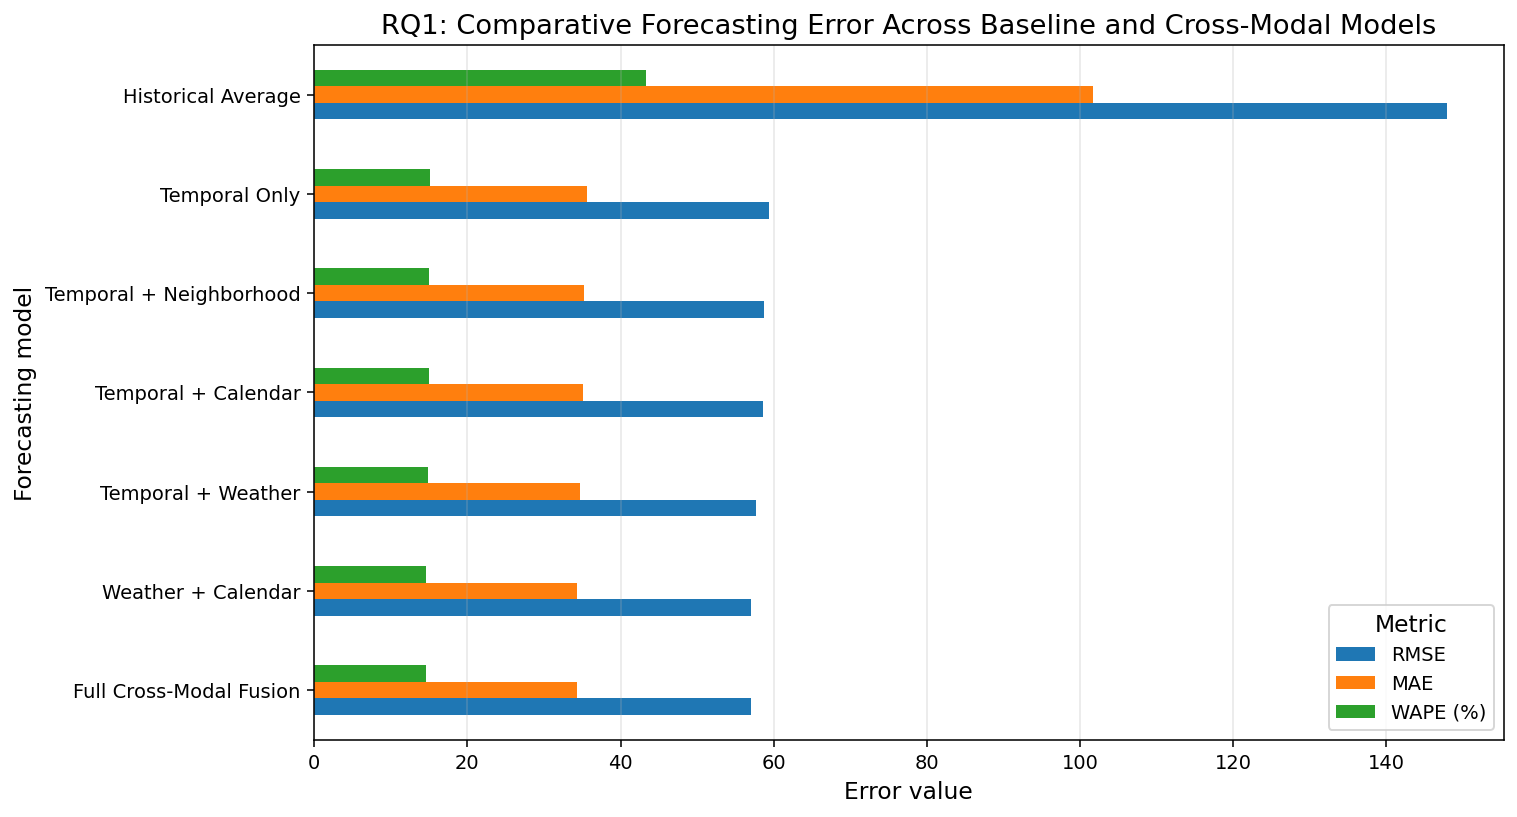

Saved figure: /kaggle/working/urban_demand_RQ1_outputs/figures_pdf/RQ1_Figure_2_multi_horizon_rmse.pdf


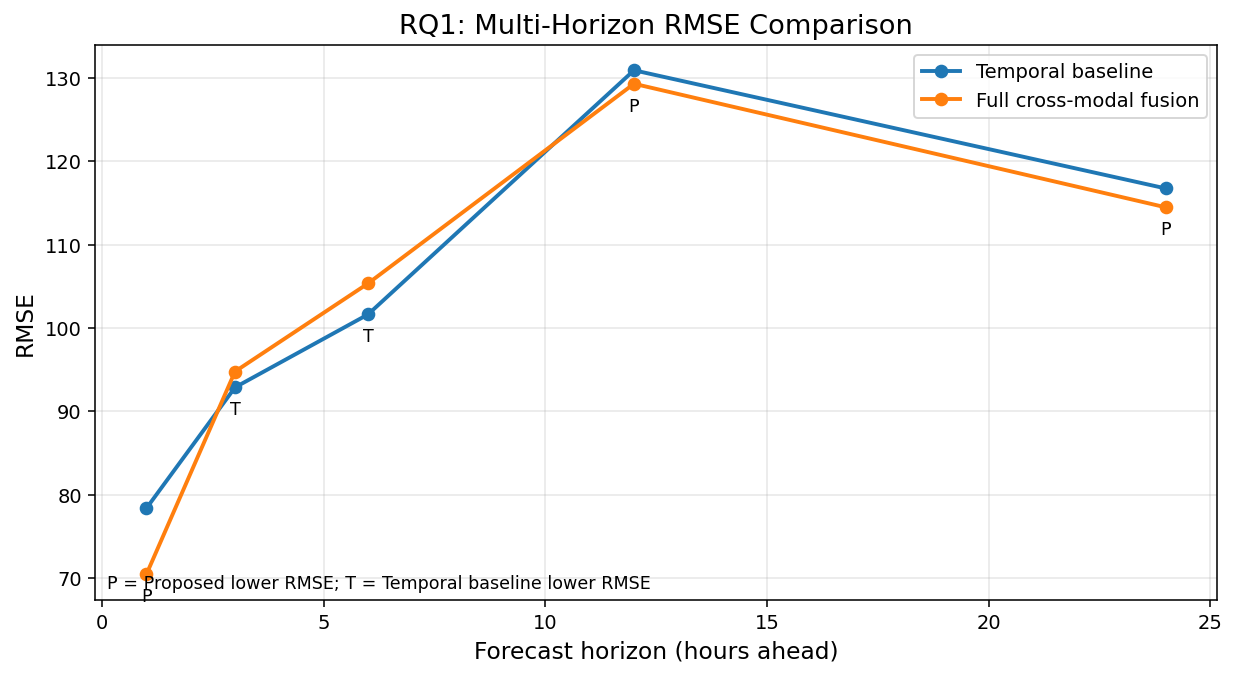

Saved figure: /kaggle/working/urban_demand_RQ1_outputs/figures_pdf/RQ1_Figure_3_actual_vs_forecast_segment.pdf


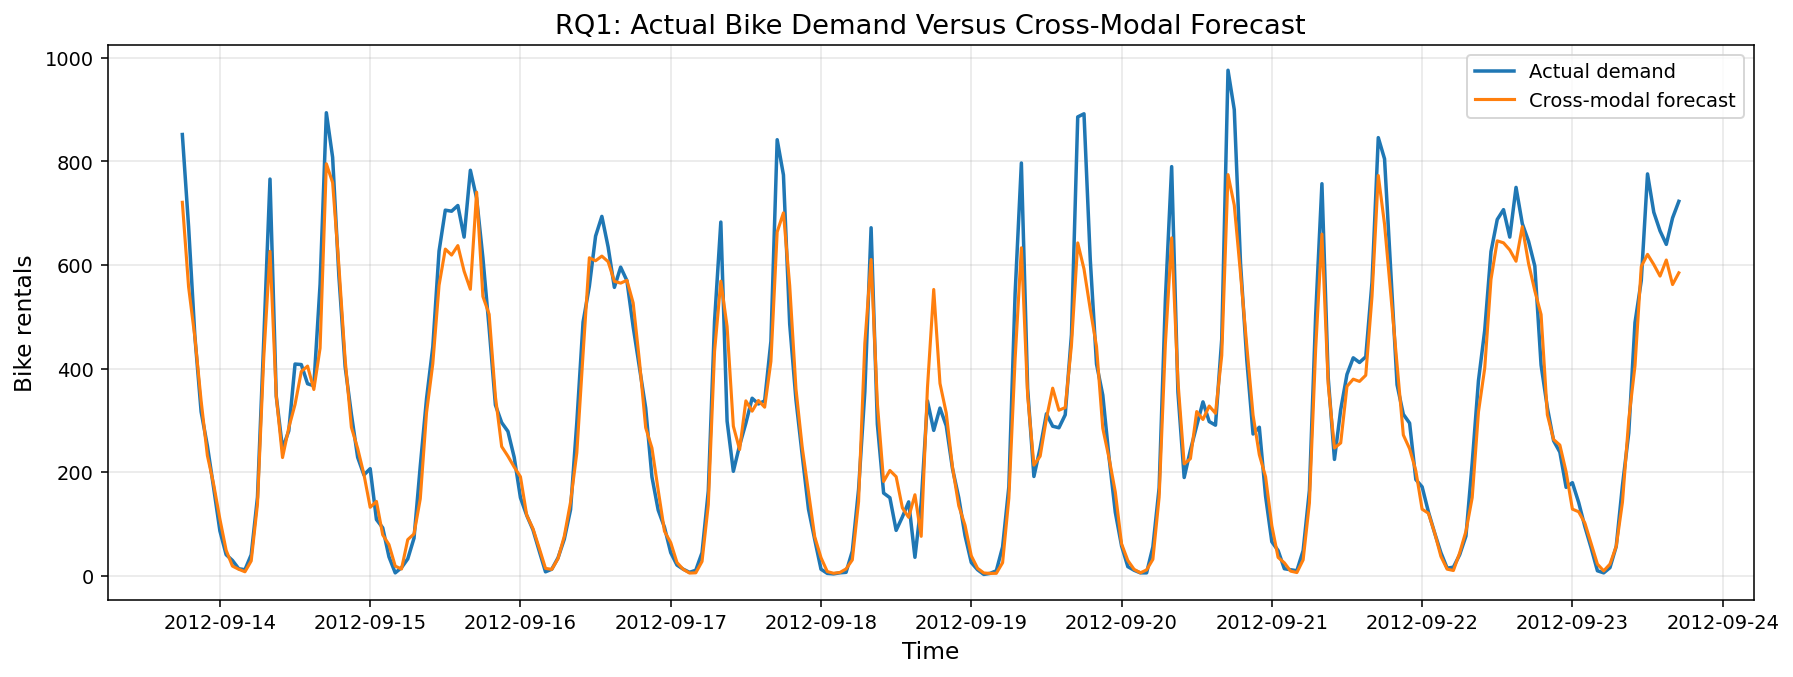

Saved figure: /kaggle/working/urban_demand_RQ1_outputs/figures_pdf/RQ1_Figure_4_error_distribution.pdf


<Figure size 1400x700 with 0 Axes>

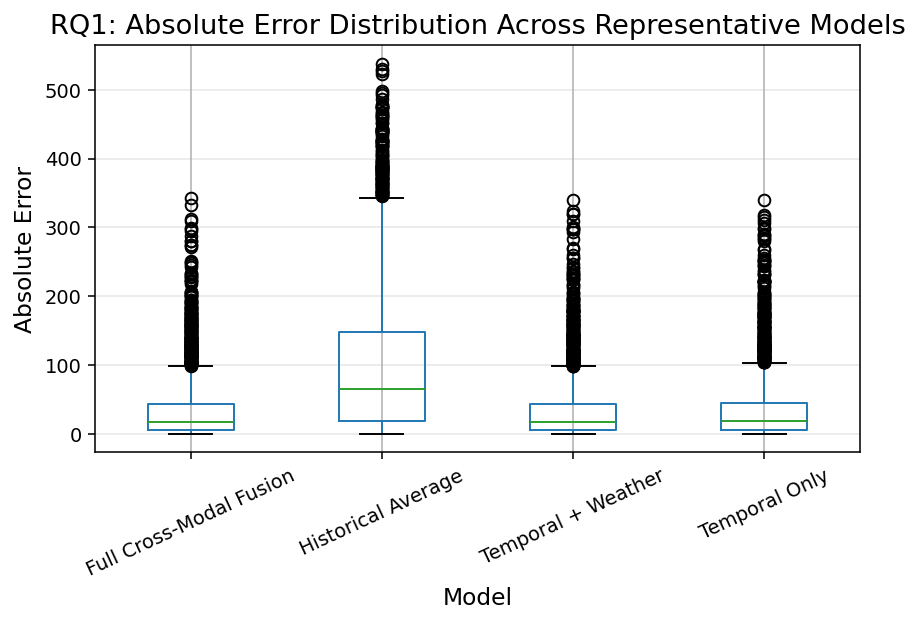

PosixPath('/kaggle/working/urban_demand_RQ1_outputs/figures_pdf/RQ1_Figure_4_error_distribution.pdf')

In [5]:

# ============================================================
# RQ1: Cross-modal fusion versus conventional and unimodal baselines
# Produces 4 figures + 3 tables.
# ============================================================
RQ = 'RQ1'
section('RQ1 — Overall effectiveness of cross-modal fusion')
variants = ['Historical Average','Temporal Only','Temporal + Weather','Temporal + Calendar','Temporal + Neighborhood','Weather + Calendar','Full Cross-Modal Fusion']
perf, preds, models = evaluate_variants(variants=variants, model_name='rf')
save_table(perf, 'RQ1_Table_1_overall_model_performance')

# Table 2: modality gain versus temporal-only baseline
base_rmse = perf.loc[perf['Model'].eq('Temporal Only'), 'RMSE'].iloc[0]
base_wape = perf.loc[perf['Model'].eq('Temporal Only'), 'WAPE (%)'].iloc[0]
gain = perf.copy()
gain['RMSE Gain vs Temporal Only (%)'] = (base_rmse - gain['RMSE'])/base_rmse*100
gain['WAPE Gain vs Temporal Only (%)'] = (base_wape - gain['WAPE (%)'])/base_wape*100
save_table(gain, 'RQ1_Table_2_modality_gain_vs_temporal')

# Table 3: multi-horizon forecasting using direct shifted targets
horizons = [1,3,6,12,24]
hrows=[]
for h in horizons:
    tmp = DATA.copy()
    tmp['target_h'] = tmp[TARGET].shift(-h)
    tmp = tmp.dropna().reset_index(drop=True)
    tr, va, te = time_split(tmp)
    # temporal baseline
    feats_base = FEATURE_SETS['Temporal Only']
    m_base = build_model('rf', feats_base)
    m_base.fit(tr[feats_base], tr['target_h'])
    pb = np.clip(m_base.predict(te[feats_base]),0,None)
    # full model
    feats_full = FEATURE_SETS['Full Cross-Modal Fusion']
    m_full = build_model('rf', feats_full)
    m_full.fit(tr[feats_full], tr['target_h'])
    pf = np.clip(m_full.predict(te[feats_full]),0,None)
    mb = metrics(te['target_h'], pb); mf = metrics(te['target_h'], pf)
    rmse_gain_pct = (mb['RMSE'] - mf['RMSE']) / mb['RMSE'] * 100
    mae_gain_pct = (mb['MAE'] - mf['MAE']) / mb['MAE'] * 100
    hrows.append({
        'Horizon':'%d hour'%h,
        'Temporal RMSE':mb['RMSE'],
        'Proposed RMSE':mf['RMSE'],
        'RMSE Gain of Proposed vs Temporal (%)':rmse_gain_pct,
        'Best Model by RMSE':'Proposed' if mf['RMSE'] < mb['RMSE'] else 'Temporal baseline',
        'Temporal MAE':mb['MAE'],
        'Proposed MAE':mf['MAE'],
        'MAE Gain of Proposed vs Temporal (%)':mae_gain_pct,
        'Temporal WAPE (%)':mb['WAPE (%)'],
        'Proposed WAPE (%)':mf['WAPE (%)']
    })
horizon_df = pd.DataFrame(hrows)
save_table(horizon_df, 'RQ1_Table_3_horizon_wise_performance')



# RQ1 automatic interpretation note for thesis writing
best_overall = perf.iloc[0]['Model']
print(f"RQ1 automatic interpretation: the lowest overall RMSE is achieved by {best_overall}.")
print("For horizon-wise results, use Table 3 and avoid claiming that the proposed model is best at every horizon if any row says 'Temporal baseline'.")

# Figure 1: thesis-ready horizontal grouped comparison across core metrics
# Horizontal layout avoids crowded model names and is easier to place in a thesis page.
plot_df = perf.set_index('Model')[['RMSE','MAE','WAPE (%)']].sort_values('RMSE', ascending=True)
ax = plot_df.plot(kind='barh', figsize=(11,6))
plt.title('RQ1: Comparative Forecasting Error Across Baseline and Cross-Modal Models')
plt.xlabel('Error value')
plt.ylabel('Forecasting model')
plt.grid(axis='x', alpha=0.3)
plt.legend(title='Metric', loc='lower right')
save_fig('RQ1_Figure_1_model_comparison_metrics')

# Figure 2: horizon-wise robustness with honest thesis-safe interpretation
plt.figure(figsize=(9,5))
plt.plot(horizons, horizon_df['Temporal RMSE'], marker='o', linewidth=2, label='Temporal baseline')
plt.plot(horizons, horizon_df['Proposed RMSE'], marker='o', linewidth=2, label='Full cross-modal fusion')
plt.title('RQ1: Multi-Horizon RMSE Comparison')
plt.xlabel('Forecast horizon (hours ahead)')
plt.ylabel('RMSE')
for _, row in horizon_df.iterrows():
    h = int(str(row['Horizon']).split()[0])
    best = row['Best Model by RMSE']
    y = min(row['Temporal RMSE'], row['Proposed RMSE'])
    plt.annotate('P' if best == 'Proposed' else 'T', xy=(h, y), xytext=(0, -14), textcoords='offset points', ha='center', fontsize=9)
plt.text(0.01, 0.02, 'P = Proposed lower RMSE; T = Temporal baseline lower RMSE', transform=plt.gca().transAxes, fontsize=9)
plt.legend()
plt.grid(alpha=0.3)
save_fig('RQ1_Figure_2_multi_horizon_rmse')

# Figure 3: actual versus predicted time-series segment
best_pred = preds['Full Cross-Modal Fusion']
seg = min(240, len(TEST))
plt.figure(figsize=(13,5))
plt.plot(TEST['datetime'].iloc[:seg], TEST[TARGET].iloc[:seg].values, label='Actual demand', linewidth=1.8)
plt.plot(TEST['datetime'].iloc[:seg], best_pred[:seg], label='Cross-modal forecast', linewidth=1.6)
plt.title('RQ1: Actual Bike Demand Versus Cross-Modal Forecast')
plt.xlabel('Time')
plt.ylabel('Bike rentals')
plt.legend()
plt.grid(alpha=0.3)
save_fig('RQ1_Figure_3_actual_vs_forecast_segment')

# Figure 4: absolute error distribution for key models
ecols = []
for name in ['Historical Average','Temporal Only','Temporal + Weather','Full Cross-Modal Fusion']:
    ecols.append(pd.DataFrame({'Model':name, 'Absolute Error':np.abs(TEST[TARGET].values - preds[name])}))
errdf = pd.concat(ecols, ignore_index=True)
plt.figure(figsize=(10,5))
errdf.boxplot(column='Absolute Error', by='Model', rot=25)
plt.title('RQ1: Absolute Error Distribution Across Representative Models')
plt.suptitle('')
plt.ylabel('Absolute Error')
plt.grid(axis='y', alpha=0.3)
save_fig('RQ1_Figure_4_error_distribution')


In [6]:

# ============================================================
# Final export: ZIP all tables and figures from this RQ
# ============================================================
zip_outputs()


Final ZIP created: /kaggle/working/urban_demand_RQ1_outputs.zip


PosixPath('/kaggle/working/urban_demand_RQ1_outputs.zip')